In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import joblib

In [3]:
df = pd.read_csv(
    "../data/processed/gps_movement_features.csv"
)

print("Total records:", len(df))

Total records: 24730077


In [4]:
coordinates = df[
    ["latitude", "longitude"]
].dropna().copy()

print("Coordinates:", len(coordinates))

Coordinates: 24730077


In [5]:
scaler = StandardScaler()

coordinates_scaled = scaler.fit_transform(
    coordinates
)

In [6]:
sample_size = min(10000, len(coordinates_scaled))

np.random.seed(42)

sample_indices = np.random.choice(
    len(coordinates_scaled),
    size=sample_size,
    replace=False
)

X_sample = coordinates_scaled[
    sample_indices
]

print("Points used for clustering:", len(X_sample))

Points used for clustering: 10000


In [8]:
kmeans = MiniBatchKMeans(
    n_clusters=10,
    batch_size=512,
    random_state=42,
    n_init=3
)

kmeans.fit(X_sample)



,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",10
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism <lower-level-parallelism-with-openmp>`on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",512
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None


In [9]:
all_labels = kmeans.predict(
    coordinates_scaled
)

print("Cluster assignment completed!")

Cluster assignment completed!


In [10]:
df["cluster"] = -1

df.loc[
    coordinates.index,
    "cluster"
] = all_labels

In [11]:
df[
    ["latitude", "longitude", "cluster"]
].head(20)

,latitude,longitude,cluster
0,39.984702,116.318417,9
1,39.984683,116.318450,9
2,39.984686,116.318417,9
3,39.984688,116.318385,9
4,39.984655,116.318263,9
5,39.984611,116.318026,9
6,39.984608,116.317761,9
7,39.984563,116.317517,9
8,39.984539,116.317294,9
9,39.984606,116.317065,9


In [12]:
cluster_counts = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

cluster
0      785358
1     5487320
2     1160492
3      170423
4      591782
5      298423
6      683587
7      324694
8      582360
9    14645638
Name: count, dtype: int64


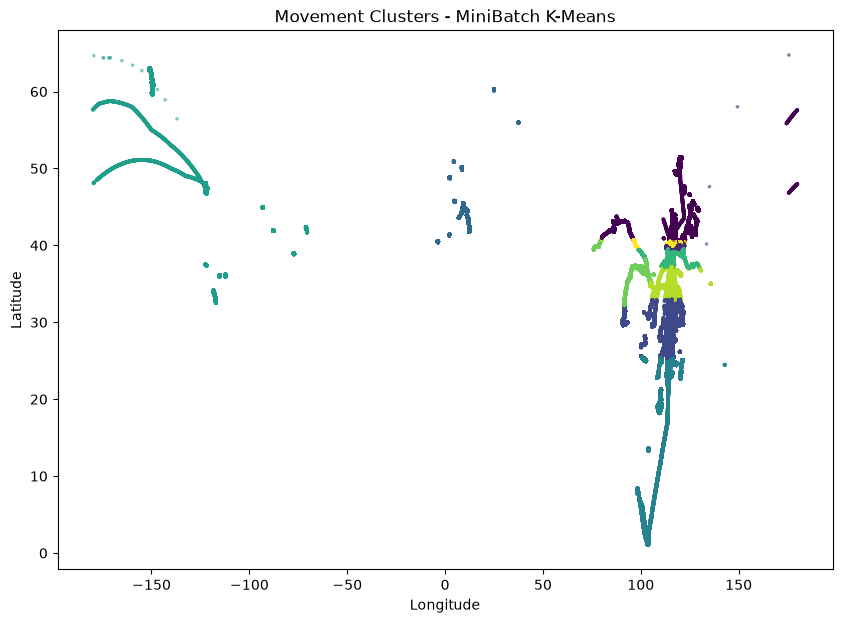

In [13]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["cluster"],
    s=3,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Movement Clusters - MiniBatch K-Means")

plt.show()

In [14]:
cluster_centers_scaled = kmeans.cluster_centers_

cluster_centers = scaler.inverse_transform(
    cluster_centers_scaled
)

cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=[
        "latitude",
        "longitude"
    ]
)

cluster_centers_df["cluster"] = range(
    len(cluster_centers_df)
)

cluster_centers_df

,latitude,longitude,cluster
0,40.900267,116.829433,0
1,39.898224,116.449113,1
2,30.525728,115.146592,2
3,45.344136,7.116037,3
4,20.158767,110.781033,4
5,42.038875,-117.526201,5
6,39.060355,116.597871,6
7,36.007719,98.020168,7
8,35.321247,114.170608,8
9,40.003865,116.301688,9


In [15]:
cluster_summary = (
    df.groupby("cluster")
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        visit_count=("cluster", "size")
    )
    .reset_index()
)

cluster_summary = cluster_summary.sort_values(
    "visit_count",
    ascending=False
)

cluster_summary

,cluster,latitude,longitude,visit_count
9,9,40.009068,116.343671,14645638
1,1,39.885085,116.514713,5487320
2,2,30.193778,114.729449,1160492
0,0,42.367534,117.556758,785358
6,6,38.561120,116.251663,683587
4,4,20.073562,111.095783,591782
8,8,34.994947,114.164560,582360
7,7,35.948550,96.992804,324694
5,5,42.804797,-117.331026,298423
3,3,44.775164,6.829885,170423


In [16]:
top_clusters = cluster_summary.head(10)

display(top_clusters)

,cluster,latitude,longitude,visit_count
9,9,40.009068,116.343671,14645638
1,1,39.885085,116.514713,5487320
2,2,30.193778,114.729449,1160492
0,0,42.367534,117.556758,785358
6,6,38.561120,116.251663,683587
4,4,20.073562,111.095783,591782
8,8,34.994947,114.164560,582360
7,7,35.948550,96.992804,324694
5,5,42.804797,-117.331026,298423
3,3,44.775164,6.829885,170423


In [17]:
total_points = cluster_summary[
    "visit_count"
].sum()

cluster_summary["visit_percentage"] = (
    cluster_summary["visit_count"]
    / total_points
    * 100
)

cluster_summary

,cluster,latitude,longitude,visit_count,visit_percentage
9,9,40.009068,116.343671,14645638,59.221967
1,1,39.885085,116.514713,5487320,22.188851
2,2,30.193778,114.729449,1160492,4.692634
0,0,42.367534,117.556758,785358,3.175720
6,6,38.561120,116.251663,683587,2.764193
4,4,20.073562,111.095783,591782,2.392965
8,8,34.994947,114.164560,582360,2.354865
7,7,35.948550,96.992804,324694,1.312952
5,5,42.804797,-117.331026,298423,1.206721
3,3,44.775164,6.829885,170423,0.689133


In [18]:
sample_labels = kmeans.labels_

score = silhouette_score(
    X_sample,
    sample_labels
)

print(
    "Silhouette Score:",
    round(score, 4)
)

Silhouette Score: 0.4483


In [19]:
df.to_csv(
    "../data/processed/gps_clustered.csv",
    index=False
)

print("Clustered dataset saved!")

Clustered dataset saved!


In [20]:
cluster_summary.to_csv(
    "../data/processed/cluster_summary.csv",
    index=False
)

print("Cluster summary saved!")

Cluster summary saved!


In [23]:
import os
import joblib


os.makedirs("../models", exist_ok=True)


joblib.dump(
    kmeans,
    "../models/clustering_model.pkl"
)


joblib.dump(
    scaler,
    "../models/clustering_scaler.pkl"
)

print("Models saved successfully!")

Models saved successfully!


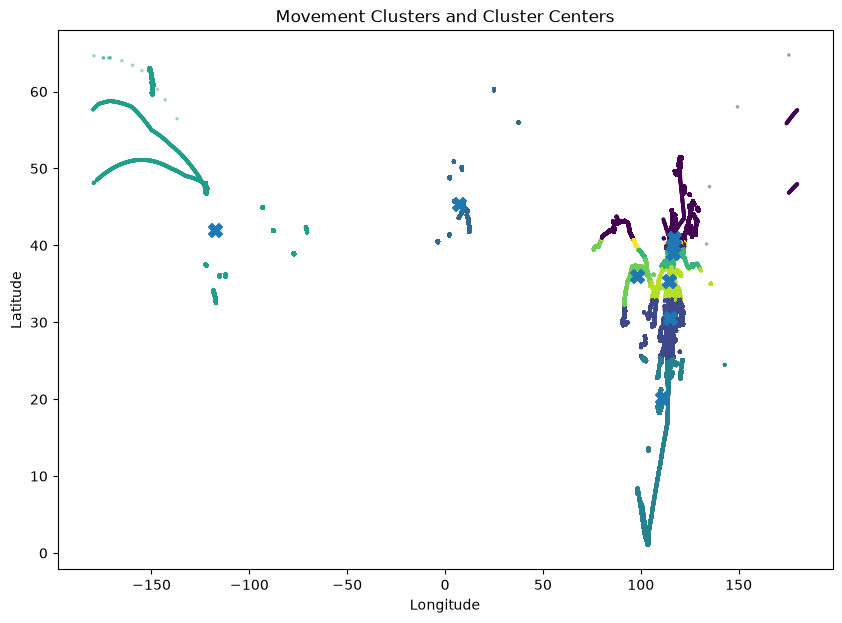

In [24]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["cluster"],
    s=3,
    alpha=0.3
)

plt.scatter(
    cluster_centers_df["longitude"],
    cluster_centers_df["latitude"],
    s=100,
    marker="X"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "Movement Clusters and Cluster Centers"
)

plt.show()

In [25]:
print("========== CLUSTERING RESULTS ==========")

print(
    "Total GPS records:",
    len(df)
)

print(
    "Number of clusters:",
    kmeans.n_clusters
)

print(
    "Silhouette Score:",
    round(score, 4)
)

print("\nTop visited areas:")

display(
    cluster_summary.head(10)
)

========== CLUSTERING RESULTS ==========
Total GPS records: 24730077
Number of clusters: 10
Silhouette Score: 0.4483

Top visited areas:


,cluster,latitude,longitude,visit_count,visit_percentage
9,9,40.009068,116.343671,14645638,59.221967
1,1,39.885085,116.514713,5487320,22.188851
2,2,30.193778,114.729449,1160492,4.692634
0,0,42.367534,117.556758,785358,3.175720
6,6,38.561120,116.251663,683587,2.764193
4,4,20.073562,111.095783,591782,2.392965
8,8,34.994947,114.164560,582360,2.354865
7,7,35.948550,96.992804,324694,1.312952
5,5,42.804797,-117.331026,298423,1.206721
3,3,44.775164,6.829885,170423,0.689133
